# Student Performance Analysis

This project analyzes student performance based on age, study hours, attendance, and assignments.

The data is loaded from an HTML table and then cleaned, transformed, analyzed, and prepared for machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
raw_df = pd.read_html(
    "student_data.html",
    flavor="bs4"
)[0]

raw_df

,Name,Age,Study Hours,Attendance,Assignments,Exam Score
0,Student A,20,15,95,18,92
1,Student B,21,10,87,15,81
2,Student C,19,18,98,20,95
3,Student D,22,8,75,12,70
4,Student E,20,13,91,17,88


In [3]:
df = raw_df.copy()

df.head()

,Name,Age,Study Hours,Attendance,Assignments,Exam Score
0,Student A,20,15,95,18,92
1,Student B,21,10,87,15,81
2,Student C,19,18,98,20,95
3,Student D,22,8,75,12,70
4,Student E,20,13,91,17,88


In [4]:
df.shape

(5, 6)

In [5]:
df.columns

Index(['Name', 'Age', 'Study Hours', 'Attendance', 'Assignments',
       'Exam Score'],
      dtype='str')

In [6]:
df.describe()

,Age,Study Hours,Attendance,Assignments,Exam Score
count,5.000000,5.000000,5.000000,5.00000,5.000000
mean,20.400000,12.800000,89.200000,16.40000,85.200000
std,1.140175,3.962323,8.955445,3.04959,9.984989
min,19.000000,8.000000,75.000000,12.00000,70.000000
25%,20.000000,10.000000,87.000000,15.00000,81.000000
50%,20.000000,13.000000,91.000000,17.00000,88.000000
75%,21.000000,15.000000,95.000000,18.00000,92.000000
max,22.000000,18.000000,98.000000,20.00000,95.000000


In [7]:
df.isnull().sum()

Name           0
Age            0
Study Hours    0
Attendance     0
Assignments    0
Exam Score     0
dtype: int64

In [8]:
df = df.dropna()

df

,Name,Age,Study Hours,Attendance,Assignments,Exam Score
0,Student A,20,15,95,18,92
1,Student B,21,10,87,15,81
2,Student C,19,18,98,20,95
3,Student D,22,8,75,12,70
4,Student E,20,13,91,17,88


In [9]:
df['Performance'] = pd.cut(
    df['Exam Score'],
    bins=[0, 59, 74, 89, 100],
    labels=['Fail', 'Pass', 'Very Good', 'Excellent']
)

df

,Name,Age,Study Hours,Attendance,Assignments,Exam Score,Performance
0,Student A,20,15,95,18,92,Excellent
1,Student B,21,10,87,15,81,Very Good
2,Student C,19,18,98,20,95,Excellent
3,Student D,22,8,75,12,70,Pass
4,Student E,20,13,91,17,88,Very Good


In [10]:
df['Performance'].value_counts()

Performance
Very Good    2
Excellent    2
Pass         1
Fail         0
Name: count, dtype: int64

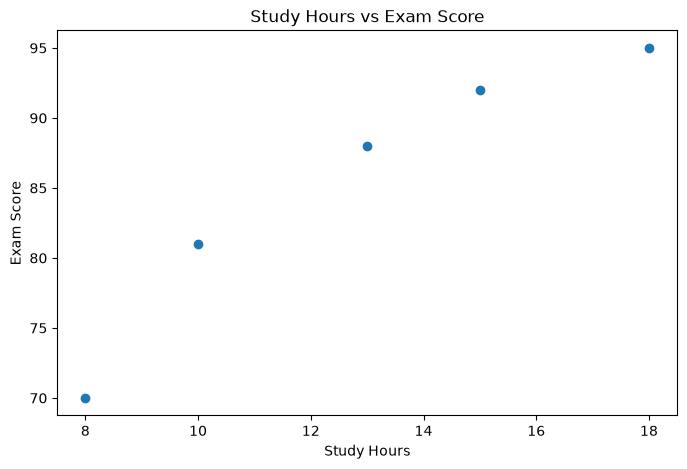

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Study Hours'],
    df['Exam Score']
)

plt.title('Study Hours vs Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')

plt.show()

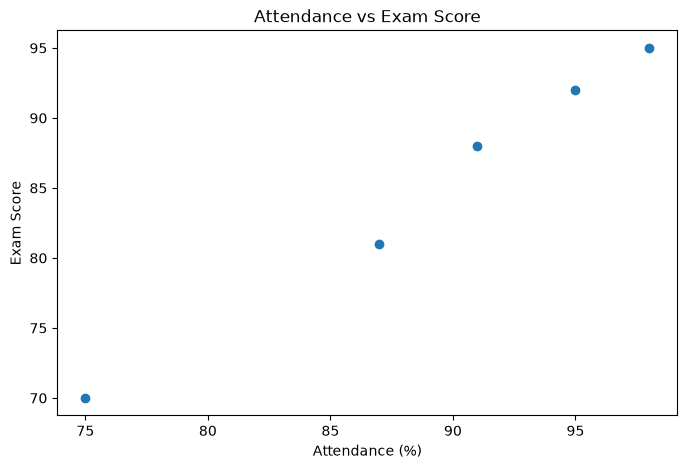

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Attendance'],
    df['Exam Score']
)

plt.title('Attendance vs Exam Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')

plt.show()

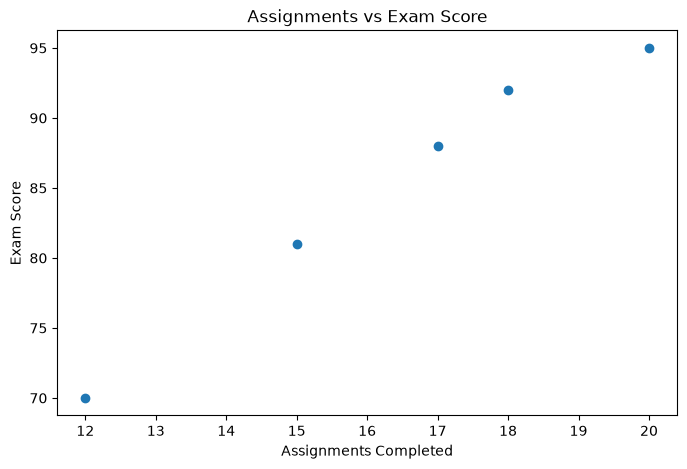

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Assignments'],
    df['Exam Score']
)

plt.title('Assignments vs Exam Score')
plt.xlabel('Assignments Completed')
plt.ylabel('Exam Score')

plt.show()

In [14]:
X = df[
    [
        'Age',
        'Study Hours',
        'Attendance',
        'Assignments'
    ]
]

y = df['Exam Score']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4, 4)
Testing data: (1, 4)


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [17]:
X_train_scaled

array([[-0.22941573, -0.13736056,  0.14091497,  0.08481889],
       [-1.14707867,  1.23624508,  0.93003882,  1.10264561],
       [-0.22941573,  0.41208169,  0.59184288,  0.42409446],
       [ 1.60591014, -1.5109662 , -1.66279667, -1.61155897]])

In [18]:
df

,Name,Age,Study Hours,Attendance,Assignments,Exam Score,Performance
0,Student A,20,15,95,18,92,Excellent
1,Student B,21,10,87,15,81,Very Good
2,Student C,19,18,98,20,95,Excellent
3,Student D,22,8,75,12,70,Pass
4,Student E,20,13,91,17,88,Very Good


## Final Student Dataset

The cleaned dataset now contains the original student information together with the calculated performance category.

In [19]:
df[
    [
        'Name',
        'Study Hours',
        'Attendance',
        'Assignments',
        'Exam Score',
        'Performance'
    ]
]

,Name,Study Hours,Attendance,Assignments,Exam Score,Performance
0,Student A,15,95,18,92,Excellent
1,Student B,10,87,15,81,Very Good
2,Student C,18,98,20,95,Excellent
3,Student D,8,75,12,70,Pass
4,Student E,13,91,17,88,Very Good


## Conclusion

The student performance dataset was loaded from an HTML table and examined using pandas.

The data was checked for missing values and cleaned before analysis. A performance category was created based on the students' exam scores.

The analysis examined the relationship between study hours, attendance, assignments, and exam scores using visualizations.

Finally, the data was prepared for machine learning by selecting input features, separating the target variable, 
splitting the dataset into training and testing sets, and applying feature scaling.